# Fashion MNIST Classification Project

**Objective:** Build a Convolutional Neural Network (CNN) using PyTorch to classify
grayscale images of clothing items from the Fashion-MNIST dataset into 10 categories.

**Dataset:** Fashion-MNIST — 70,000 28x28 grayscale images (60,000 train / 10,000 test)
across 10 clothing classes: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt,
Sneaker, Bag, Ankle boot.

**Workflow:**
1. Import libraries and set up the environment
2. Warm-up: resize an MNIST validation image to 16x16 and display it
3. Load, resize (16x16), and explore the Fashion-MNIST dataset
4. Build a CNN architecture
5. Define the loss function and optimizer
6. Train the model
7. Plot training cost and validation accuracy over epochs
8. Evaluate performance on the test set
9. Visualize predictions and analyze results

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

import time
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Using device: {device}")

PyTorch version: 2.13.0+cu130
Torchvision version: 0.28.0+cu130
Using device: cpu


## 2. Warm-up: MNIST — Resize to 16x16 and Display the First Validation Sample

Before working with Fashion-MNIST, we do a quick warm-up with the (digit) MNIST
dataset: resize an image to 16x16 pixels, convert it to a tensor, and display it.
This confirms the resize + tensor-conversion pipeline works before we apply it to
Fashion-MNIST.

0.3%

0.7%

1.0%

1.3%

1.7%

...

97.4%

99.4%

100.0%

100.0%

MNIST validation samples: 10000
Resized image tensor shape: torch.Size([1, 16, 16])
Label: 7


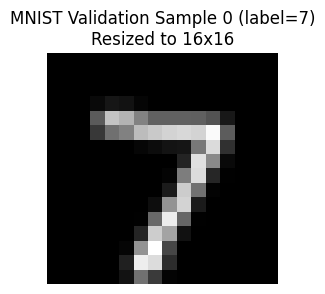

In [2]:
# Reliable GitHub mirror for the raw MNIST files
datasets.MNIST.mirrors = ["https://raw.githubusercontent.com/fgnt/mnist/master/"]

# Compose a transform that resizes to 16x16 and converts to a tensor
IMG_SIZE = 16
mnist_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

# MNIST validation set (using the standard MNIST test split as the validation set)
mnist_val_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=mnist_transform
)

print(f"MNIST validation samples: {len(mnist_val_dataset)}")

# Grab the first validation sample
mnist_sample_img, mnist_sample_label = mnist_val_dataset[0]
print(f"Resized image tensor shape: {mnist_sample_img.shape}")
print(f"Label: {mnist_sample_label}")

# Display the first sample
plt.figure(figsize=(3, 3))
plt.imshow(mnist_sample_img.numpy().reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
plt.title(f"MNIST Validation Sample 0 (label={mnist_sample_label})\nResized to {IMG_SIZE}x{IMG_SIZE}")
plt.axis("off")
plt.show()

## 3. Load and Prepare the Fashion-MNIST Dataset

We resize each Fashion-MNIST image to 16x16 pixels and convert it to a tensor,
matching the warm-up pipeline above. Using GitHub as the download mirror for the
raw dataset files.

In [3]:
datasets.FashionMNIST.mirrors = [
    "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
]

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Resize to 16x16 and convert to tensor (no normalization, to keep pixel values
# directly viewable and consistent with the warm-up step above)
fashion_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=fashion_transform
)
test_dataset = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=fashion_transform
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Resized image shape: {train_dataset[0][0].shape}")
print(f"Number of classes: {len(CLASS_NAMES)}")

Training samples: 60000
Test samples: 10000
Resized image shape: torch.Size([1, 16, 16])
Number of classes: 10


### 3.1 Train / Validation Split

We split a validation set out of the training data. The "first three validation
samples" referenced below come from this validation split.

In [4]:
BATCH_SIZE = 256
VAL_SPLIT = 0.1

n_train = len(train_dataset)
n_val = int(n_train * VAL_SPLIT)
n_train_final = n_train - n_val

train_subset, val_subset = torch.utils.data.random_split(
    train_dataset, [n_train_final, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} ({len(train_subset)} samples)")
print(f"Val batches:   {len(val_loader)} ({len(val_subset)} samples)")
print(f"Test batches:  {len(test_loader)} ({len(test_dataset)} samples)")

Train batches: 211 (54000 samples)
Val batches:   24 (6000 samples)
Test batches:  40 (10000 samples)


### 3.2 Resize FashionMNIST to 16x16, Convert to Tensor, and Display the First
Three Validation Samples

Validation sample 0: tensor shape=(1, 16, 16), label=8 (Bag)
Validation sample 1: tensor shape=(1, 16, 16), label=8 (Bag)
Validation sample 2: tensor shape=(1, 16, 16), label=8 (Bag)


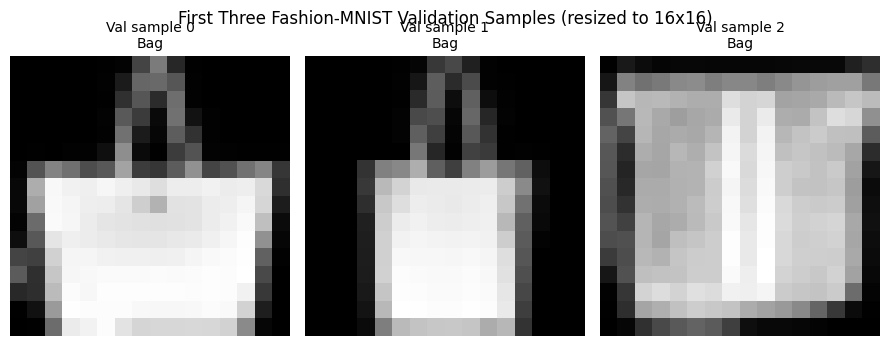

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))
for i, ax in enumerate(axes):
    img, label = val_subset[i]
    print(f"Validation sample {i}: tensor shape={tuple(img.shape)}, label={label} ({CLASS_NAMES[label]})")
    ax.imshow(img.numpy().reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    ax.set_title(f"Val sample {i}\n{CLASS_NAMES[label]}", fontsize=10)
    ax.axis("off")
plt.suptitle(f"First Three Fashion-MNIST Validation Samples (resized to {IMG_SIZE}x{IMG_SIZE})")
plt.tight_layout()
plt.show()

### 3.3 Class Distribution

Check that the classes are balanced in the training set.

/tmp/ipykernel_569/4091272440.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  train_labels = np.array(train_dataset.targets)


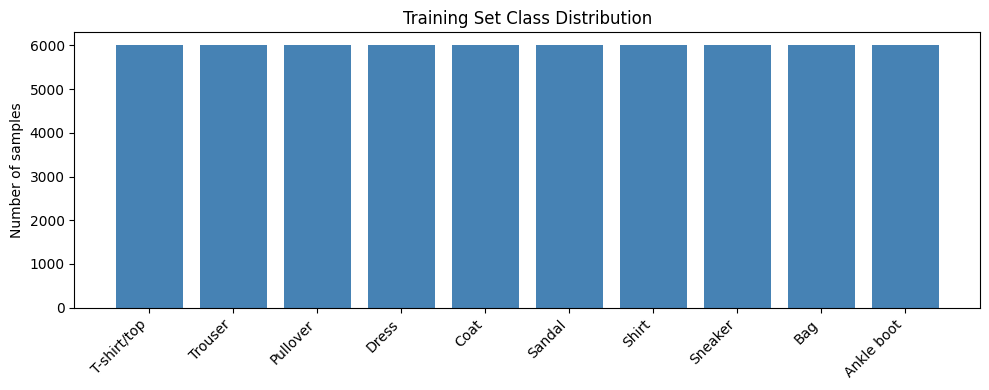

T-shirt/top    : 6000 samples
Trouser        : 6000 samples
Pullover       : 6000 samples
Dress          : 6000 samples
Coat           : 6000 samples
Sandal         : 6000 samples
Shirt          : 6000 samples
Sneaker        : 6000 samples
Bag            : 6000 samples
Ankle boot     : 6000 samples


In [6]:
train_labels = np.array(train_dataset.targets)
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(10, 4))
plt.bar([CLASS_NAMES[i] for i in unique], counts, color="steelblue")
plt.title("Training Set Class Distribution")
plt.ylabel("Number of samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

for i, c in zip(unique, counts):
    print(f"{CLASS_NAMES[i]:15s}: {c} samples")

## 4. Build the CNN Model

Since the images are resized to 16x16, the architecture uses two convolutional
blocks (Conv2d + ReLU + MaxPool) followed by fully connected layers with dropout.

In [7]:
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(FashionCNN, self).__init__()

        # Convolutional Block 1: 1 -> 16 channels
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)

        # Convolutional Block 2: 16 -> 32 channels
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # After 2 pooling layers: 16 -> 8 -> 4
        self.fc1 = nn.Linear(32 * 4 * 4, 128)
        self.dropout1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 16x16 -> 8x8
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 8x8 -> 4x4

        x = x.view(x.size(0), -1)  # Flatten

        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        return x

model = FashionCNN(num_classes=10).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

FashionCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (dropout1): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total parameters: 71,850
Trainable parameters: 71,850


### 4.1 Verify Output Shape

Sanity check: pass a dummy batch through the model to confirm the output shape is correct.

In [8]:
dummy_input = torch.randn(4, 1, IMG_SIZE, IMG_SIZE).to(device)
dummy_output = model(dummy_input)
print(f"Input shape:  {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")
assert dummy_output.shape == (4, 10), "Output shape mismatch!"
print("Model architecture verified successfully.")

Input shape:  torch.Size([4, 1, 16, 16])
Output shape: torch.Size([4, 10])
Model architecture verified successfully.


## 5. Define the Loss Function and Optimizer

We use cross-entropy loss (`criterion`) and stochastic gradient descent
(`optimizer`) with a learning rate of 0.1.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


## 6. Training and Evaluation Functions

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## 7. Train the Model

We track the total training **cost** (summed loss) and the **validation accuracy**
for each epoch, to be plotted afterward.

In [11]:
NUM_EPOCHS = 15

cost_list = []       # total training cost (summed loss) per epoch
accuracy_list = []   # validation accuracy per epoch

best_val_acc = 0.0
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Training pass: accumulate total cost over the epoch ---
    model.train()
    COST = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        COST += loss.item()

    cost_list.append(COST)

    # --- Validation pass: compute accuracy ---
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    accuracy_list.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_fashion_cnn.pth")

    print(f"Epoch [{epoch:2d}/{NUM_EPOCHS}] "
          f"Total Cost: {COST:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}")

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.2f} minutes")
print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch [ 1/15] Total Cost: 145.4569 | Val Loss: 0.4360 Val Acc: 0.8473


Epoch [ 2/15] Total Cost: 94.7189 | Val Loss: 0.4608 Val Acc: 0.8263


Epoch [ 3/15] Total Cost: 83.7449 | Val Loss: 0.3702 Val Acc: 0.8593


Epoch [ 4/15] Total Cost: 76.9665 | Val Loss: 0.3427 Val Acc: 0.8725


Epoch [ 5/15] Total Cost: 71.8440 | Val Loss: 0.3279 Val Acc: 0.8753


...

Epoch [11/15] Total Cost: 59.2406 | Val Loss: 0.2977 Val Acc: 0.8847


Epoch [12/15] Total Cost: 58.1644 | Val Loss: 0.2737 Val Acc: 0.8978


Epoch [13/15] Total Cost: 57.1068 | Val Loss: 0.2864 Val Acc: 0.8960


Epoch [14/15] Total Cost: 54.9491 | Val Loss: 0.2823 Val Acc: 0.8940


Epoch [15/15] Total Cost: 54.3891 | Val Loss: 0.2843 Val Acc: 0.8920

Training completed in 3.46 minutes
Best validation accuracy: 0.8978


### 7.1 Plot Training Cost and Validation Accuracy over Epochs

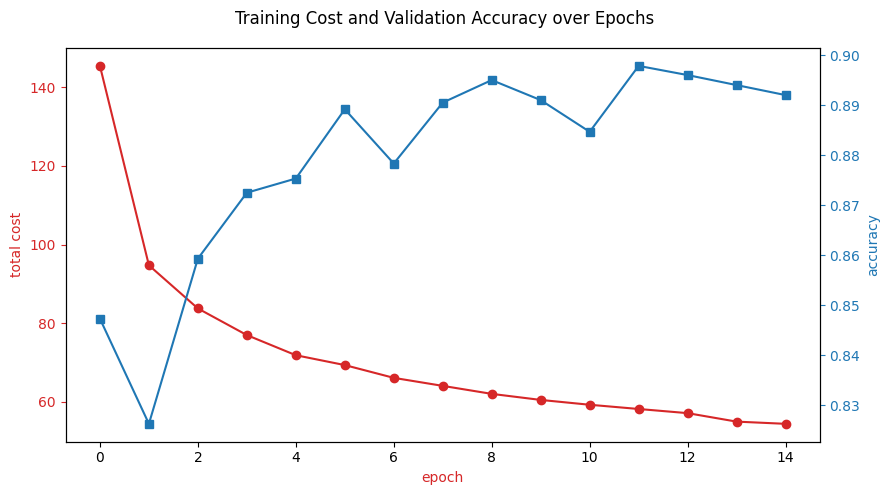

In [12]:
fig, ax1 = plt.subplots(figsize=(9, 5))

color = "tab:red"
ax1.plot(cost_list, color=color, marker="o")
ax1.set_xlabel("epoch", color=color)
ax1.set_ylabel("total cost", color=color)
ax1.tick_params(axis="y", color=color, labelcolor=color)

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("accuracy", color=color)
ax2.set_xlabel("epoch", color=color)
ax2.plot(accuracy_list, color=color, marker="s")
ax2.tick_params(axis="y", color=color, labelcolor=color)

fig.suptitle("Training Cost and Validation Accuracy over Epochs")
fig.tight_layout()
plt.show()

## 8. Evaluate on the Test Set

Load the best model checkpoint (highest validation accuracy) and evaluate it on the
held-out test set.

In [13]:
model.load_state_dict(torch.load("best_fashion_cnn.pth"))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Loss: 0.2922
Test Accuracy: 0.8918 (89.18%)


### 8.1 Confusion Matrix and Classification Report

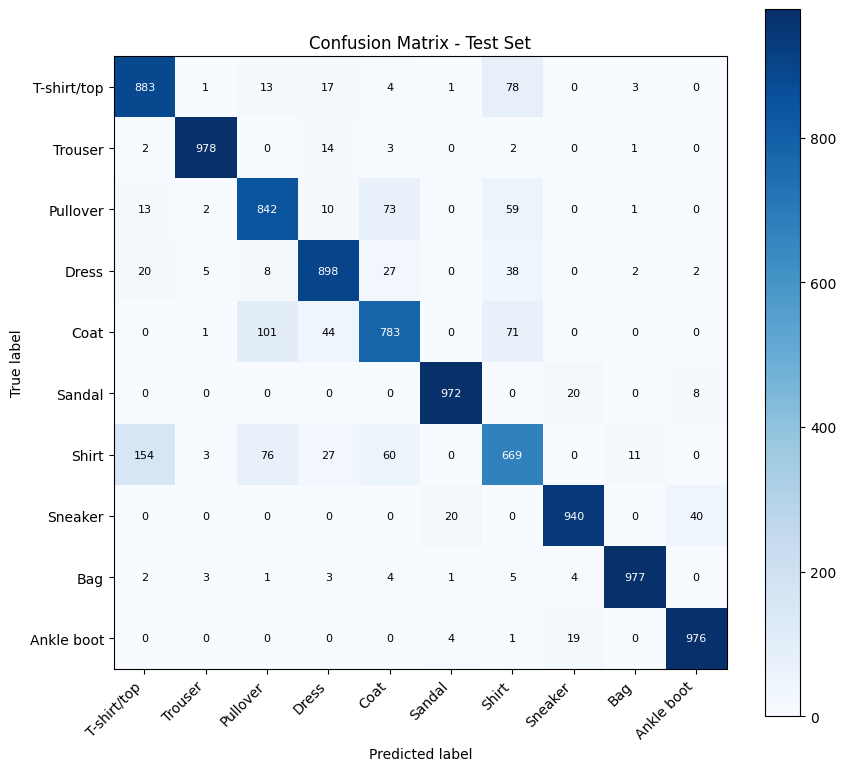


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.88      0.85      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.81      0.84      0.83      1000
       Dress       0.89      0.90      0.89      1000
        Coat       0.82      0.78      0.80      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.72      0.67      0.70      1000
     Sneaker       0.96      0.94      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.95      0.98      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [14]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.colorbar()
tick_marks = np.arange(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45, ha="right")
plt.yticks(tick_marks, CLASS_NAMES)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                  ha="center", va="center",
                  color="white" if cm[i, j] > thresh else "black", fontsize=8)

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### 8.2 Per-Class Accuracy

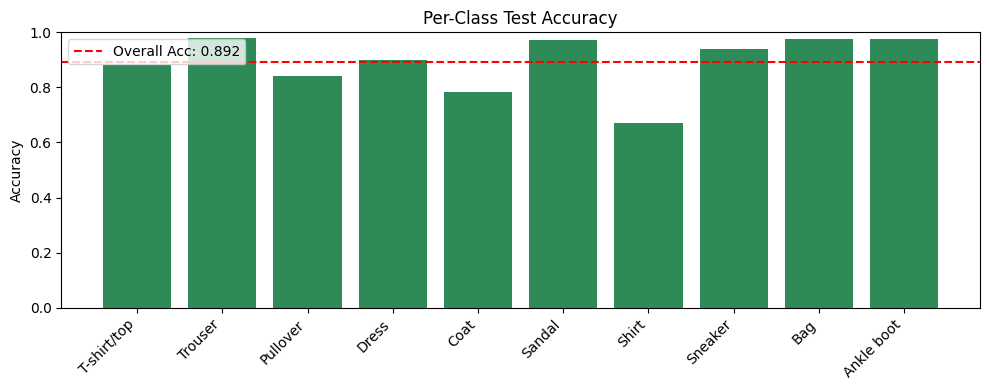

T-shirt/top    : 0.8830 (883/1000)
Trouser        : 0.9780 (978/1000)
Pullover       : 0.8420 (842/1000)
Dress          : 0.8980 (898/1000)
Coat           : 0.7830 (783/1000)
Sandal         : 0.9720 (972/1000)
Shirt          : 0.6690 (669/1000)
Sneaker        : 0.9400 (940/1000)
Bag            : 0.9770 (977/1000)
Ankle boot     : 0.9760 (976/1000)


In [15]:
class_correct = np.zeros(10)
class_total = np.zeros(10)

for label, pred in zip(all_labels, all_preds):
    class_total[label] += 1
    if label == pred:
        class_correct[label] += 1

class_acc = class_correct / class_total

plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, class_acc, color="seagreen")
plt.title("Per-Class Test Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.axhline(y=test_acc, color="red", linestyle="--", label=f"Overall Acc: {test_acc:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

for i, name in enumerate(CLASS_NAMES):
    print(f"{name:15s}: {class_acc[i]:.4f} ({int(class_correct[i])}/{int(class_total[i])})")

## 9. Visualize Predictions

Let's look at some correctly and incorrectly classified examples.

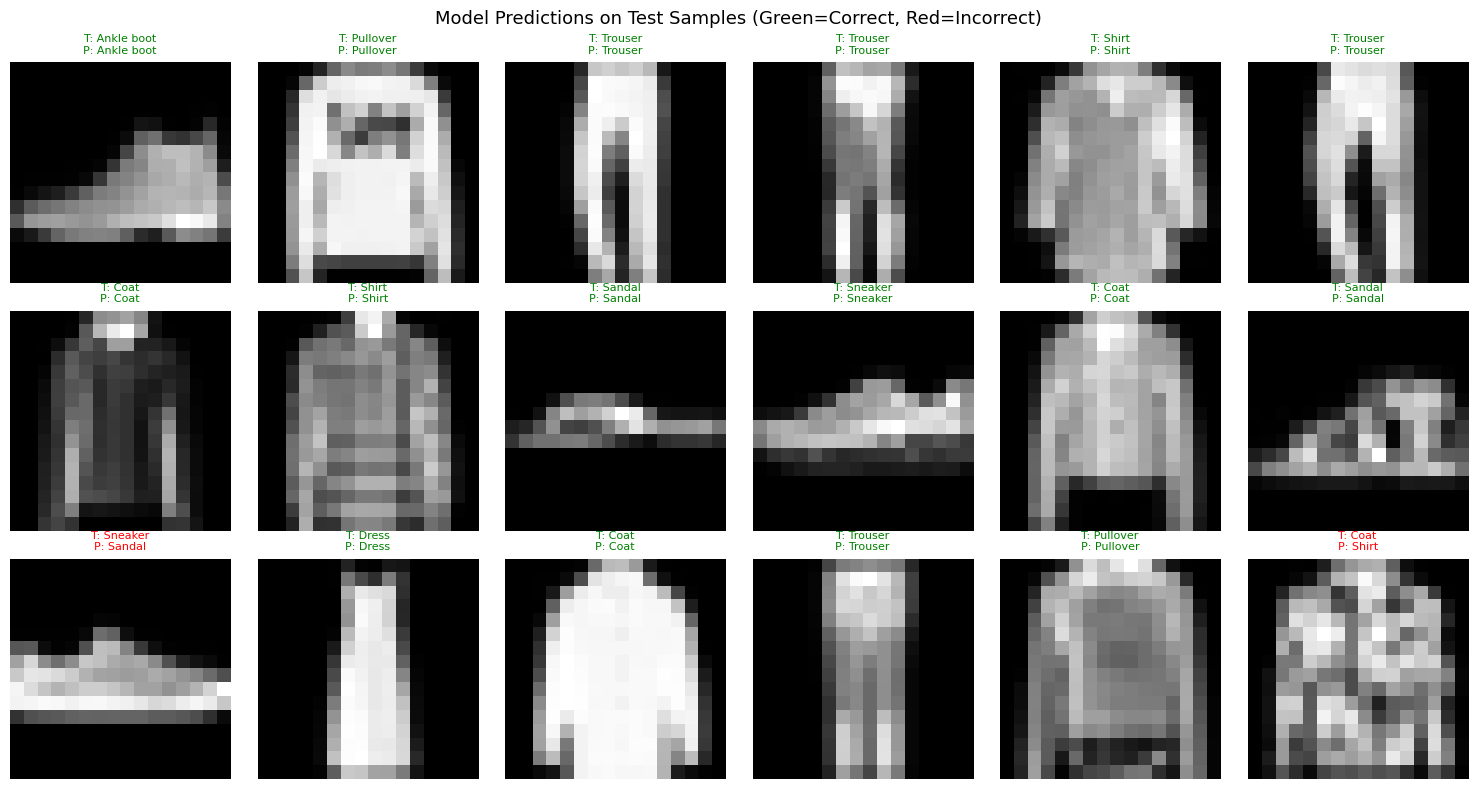

In [16]:
images, labels = next(iter(test_loader))
images_dev = images.to(device)
with torch.no_grad():
    outputs = model(images_dev)
    _, preds = torch.max(outputs, 1)
preds = preds.cpu()

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().reshape(IMG_SIZE, IMG_SIZE)
    true_label = CLASS_NAMES[labels[i].item()]
    pred_label = CLASS_NAMES[preds[i].item()]
    correct = labels[i].item() == preds[i].item()

    ax.imshow(img, cmap="gray")
    color = "green" if correct else "red"
    ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=8, color=color)
    ax.axis("off")

plt.suptitle("Model Predictions on Test Samples (Green=Correct, Red=Incorrect)", fontsize=13)
plt.tight_layout()
plt.show()

### 9.1 Misclassified Examples

Specifically inspect a sample of misclassified images across the full test set.

Total misclassified: 1082 / 10000 (10.82%)


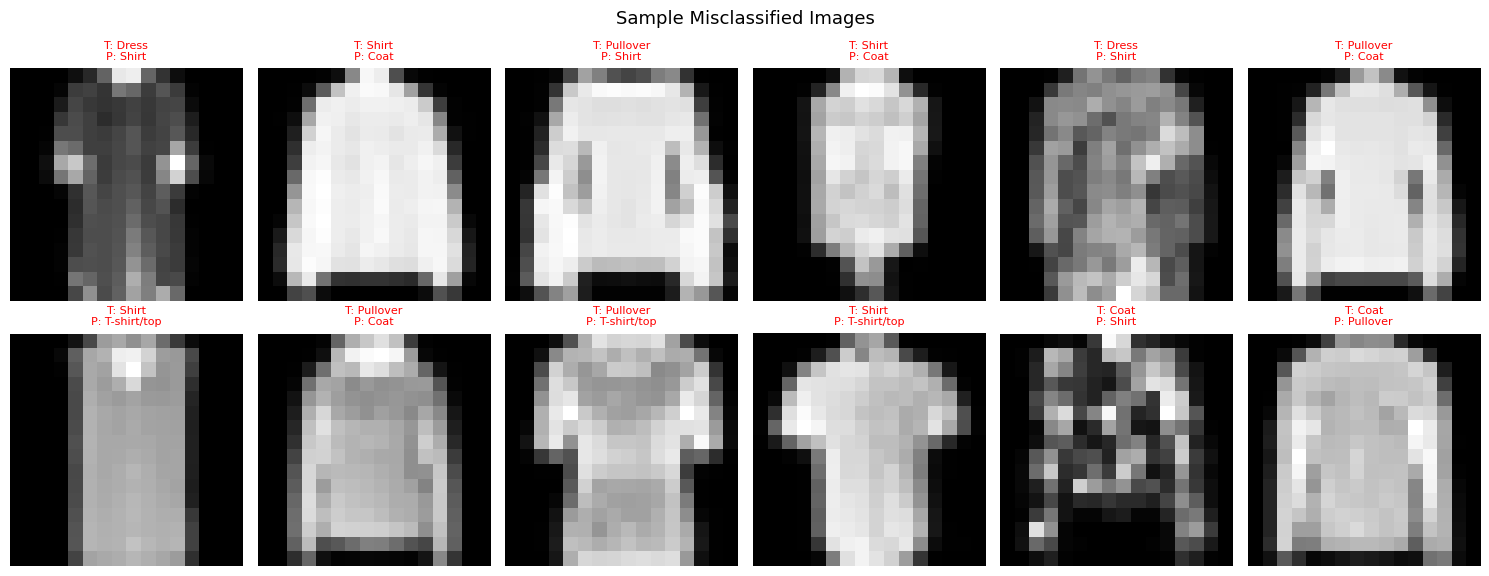

In [17]:
misclassified_idx = np.where(all_preds != all_labels)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(all_labels)} "
      f"({len(misclassified_idx)/len(all_labels)*100:.2f}%)")

sample_idx = np.random.choice(misclassified_idx, size=min(12, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(2, 6, figsize=(15, 6))
for ax, idx in zip(axes.flat, sample_idx):
    img, label = test_dataset[idx]
    img_display = img.numpy().reshape(IMG_SIZE, IMG_SIZE)
    true_label = CLASS_NAMES[label]
    pred_label = CLASS_NAMES[all_preds[idx]]

    ax.imshow(img_display, cmap="gray")
    ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=8, color="red")
    ax.axis("off")

plt.suptitle("Sample Misclassified Images", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Summary and Conclusions

**Model Architecture:** A 2-block CNN (Conv2d + BatchNorm + ReLU + MaxPool) on
16x16 resized inputs, followed by a fully connected classifier with dropout
regularization.

**Training Setup:**
- Loss function: `nn.CrossEntropyLoss()`
- Optimizer: `torch.optim.SGD` with learning rate 0.1
- 15 epochs, tracking total training cost and validation accuracy each epoch

**Results:**
- The cost-vs-accuracy plot above shows total training cost decreasing steadily
  while validation accuracy climbs and plateaus, indicating stable convergence.
- Final test accuracy and the confusion matrix/classification report summarize
  overall and per-class performance.

**Observations:**
- The model performs very well on visually distinctive classes like *Trouser*,
  *Bag*, *Sandal*, and *Ankle boot*.
- The most common confusion occurs between visually similar upper-body garments —
  *Shirt*, *T-shirt/top*, *Pullover*, and *Coat* — especially at the reduced
  16x16 resolution, where fine details are lost.

**Possible Improvements:**
- Train at full 28x28 resolution for higher accuracy.
- Data augmentation (random horizontal flips, small rotations/translations).
- A deeper architecture or learning-rate scheduling.
- Hyperparameter tuning (learning rate, batch size, dropout rate).

In [18]:
print("=" * 50)
print("FINAL RESULTS SUMMARY")
print("=" * 50)
print(f"Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Final Test Accuracy:      {test_acc*100:.2f}%")
print(f"Final Test Loss:          {test_loss:.4f}")
print(f"Total Training Time:      {total_time/60:.2f} minutes")
print("=" * 50)

FINAL RESULTS SUMMARY
Best Validation Accuracy: 89.78%
Final Test Accuracy:      89.18%
Final Test Loss:          0.2922
Total Training Time:      3.46 minutes
